# 06 — Multi-seed robustness and cost-function ablation

Addresses two required points from the external methods review (`review/reviewer_report.md`):

- **M2 (single realisation → no uncertainty).** Notebooks 03-04 rested every headline number on one (LUT seed 42, truth seed 1234, noise seed 0) draw. This notebook repeats the full spectral-subset comparison over 30 independent seed triples and reports mean ± SD, so the "±100 nm SWIR beats full hyperspectral" gap for Cw/Cm carries an actual uncertainty band.
- **M1 (unweighted-SSR cost is a possible confound).** The original inversion cost (`invert_lut_batch`'s default) is raw sum-of-squared residuals in reflectance units — it mechanically over-weights the bright NIR plateau relative to the low-reflectance SWIR water features, which could by itself explain why the full 366-band set underperforms a targeted ±100–200 nm SWIR subset. This notebook re-runs the *same* seed-repeated comparison under two additional costs — `noise_normalized` (weighted by this scene's own measured per-band `surface_reflectance_uncertainty`) and `sam` (Spectral Angle Mapper, scale-invariant by construction) — to test whether the "targeted SWIR ≥ full hyperspectral" finding survives a cost function that cannot be confounded by band-magnitude imbalance.

**Both questions are answered by one experiment run** (`src/experiments.run_subset_experiment`, seeded identically across costs so cost differences aren't confounded by realisation differences).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
from src import tanager_io, experiments, channel_selector as cs

## Scene, subsets, and real per-band noise

`band_sigma` for the `noise_normalized` cost is the scene's own measured `surface_reflectance_uncertainty`, per band (median over valid pixels) — not an assumed value.

In [2]:
import h5py

SCENE_SR_PATH = Path("../data/tanager_scene_01/scene_basic_sr.h5")
scene = tanager_io.load_surface_reflectance(SCENE_SR_PATH)
wavelengths = scene.wavelengths
invalid_pixels = scene.cloud_mask | scene.cirrus_mask | scene.nodata_mask
mean_sun_zenith = float(np.nanmean(scene.sun_zenith[~invalid_pixels]))

valid_bands = cs.valid_band_mask(wavelengths)

with h5py.File(SCENE_SR_PATH, "r") as f:
    unc = f["HDFEOS/SWATHS/HYP/Data Fields/surface_reflectance_uncertainty"][()]
    refl = f["HDFEOS/SWATHS/HYP/Data Fields/surface_reflectance"][()]
valid_px = (refl > -1) & (refl < 2) & (unc > 0) & (unc < 1)
band_sigma = np.array([np.median(unc[b][valid_px[b]]) for b in range(unc.shape[0])])
print(f"band_sigma: min={band_sigma.min():.5f}, median={np.median(band_sigma):.5f}, max={band_sigma.max():.5f}")

swir_masks = cs.swir_incremental_subsets(wavelengths, cs.MULTISPECTRAL_BANDS_NM, swir_window_nm=50.0, n_steps=4)
subset_labels = ["5-band multispectral (no SWIR)"] + [f"+ SWIR window \u00b1{50*step} nm" for step in range(1, 5)]
subset_masks = list(swir_masks)
subset_labels.append("Full hyperspectral (valid bands)")
subset_masks.append(valid_bands)

for label, mask in zip(subset_labels, subset_masks):
    print(f"{label}: {mask.sum()} bands")

band_sigma: min=0.00090, median=0.00135, max=0.36133
5-band multispectral (no SWIR): 5 bands
+ SWIR window ±50 nm: 45 bands
+ SWIR window ±100 nm: 85 bands
+ SWIR window ±150 nm: 125 bands
+ SWIR window ±200 nm: 165 bands
Full hyperspectral (valid bands): 366 bands


## Run: 30 independent seed triples × 3 costs × 6 subsets

Same reference-LUT size (8000), truth-set size (300), and noise level (\u03c3 = 0.005) as notebooks 03-05, so this is a direct robustness/ablation extension of those results, not a different experiment. The 30 seed triples are deterministic (derived from a fixed master seed) so this notebook is itself reproducible.

In [3]:
N_SEEDS = 30
master_rng = np.random.default_rng(2026)
seed_triples = [
    tuple(int(x) for x in master_rng.integers(0, 1_000_000, size=3)) for _ in range(N_SEEDS)
]

df = experiments.run_subset_experiment(
    seed_triples=seed_triples,
    subset_masks=subset_masks,
    subset_labels=subset_labels,
    wavelengths=wavelengths,
    tts=mean_sun_zenith,
    costs=("sse", "noise_normalized", "sam"),
    band_sigma=band_sigma,
    n_reference_lut=8000,
    n_truth=300,
    noise_sigma=0.005,
)
df.to_csv("../results/tables/06_multiseed_cost_raw.csv", index=False)
print(df.shape)
df.head()

(3780, 11)


,seed_idx,lut_seed,truth_seed,noise_seed,cost,subset,n_bands,parameter,rmse,r_squared,relative_rmse_pct
0,0,851852,178934,26417,sse,5-band multispectral (no SWIR),5,N,0.439777,-0.031257,29.318497
1,0,851852,178934,26417,sse,5-band multispectral (no SWIR),5,Cab,7.228543,0.902036,9.035679
2,0,851852,178934,26417,sse,5-band multispectral (no SWIR),5,Car,7.579558,-0.723354,37.897788
3,0,851852,178934,26417,sse,5-band multispectral (no SWIR),5,Ant,1.966078,0.536145,19.660785
4,0,851852,178934,26417,sse,5-band multispectral (no SWIR),5,Cw,0.020892,-1.272212,43.524954


## A1 result — multi-seed robustness (canonical cost = sse)

In [4]:
summary = experiments.summarize(df)
summary.to_csv("../results/tables/06_multiseed_subset_stats.csv", index=False)

sse_summary = summary[summary["cost"] == "sse"]
cw_sse = sse_summary[sse_summary["parameter"] == "Cw"].set_index("subset").loc[subset_labels]
cw_sse[["n_bands", "r_squared_mean", "r_squared_sd", "relative_rmse_pct_mean", "relative_rmse_pct_sd"]]

,n_bands,r_squared_mean,r_squared_sd,relative_rmse_pct_mean,relative_rmse_pct_sd
subset,,,,,
5-band multispectral (no SWIR),5,-0.982775,0.118467,40.631855,1.214996
+ SWIR window ±50 nm,45,0.835990,0.012009,11.683397,0.429301
+ SWIR window ±100 nm,85,0.907053,0.009709,8.789356,0.461475
+ SWIR window ±150 nm,125,0.912500,0.009256,8.527903,0.447804
+ SWIR window ±200 nm,165,0.913076,0.009697,8.498221,0.476286
Full hyperspectral (valid bands),366,0.878135,0.010770,10.068026,0.447598


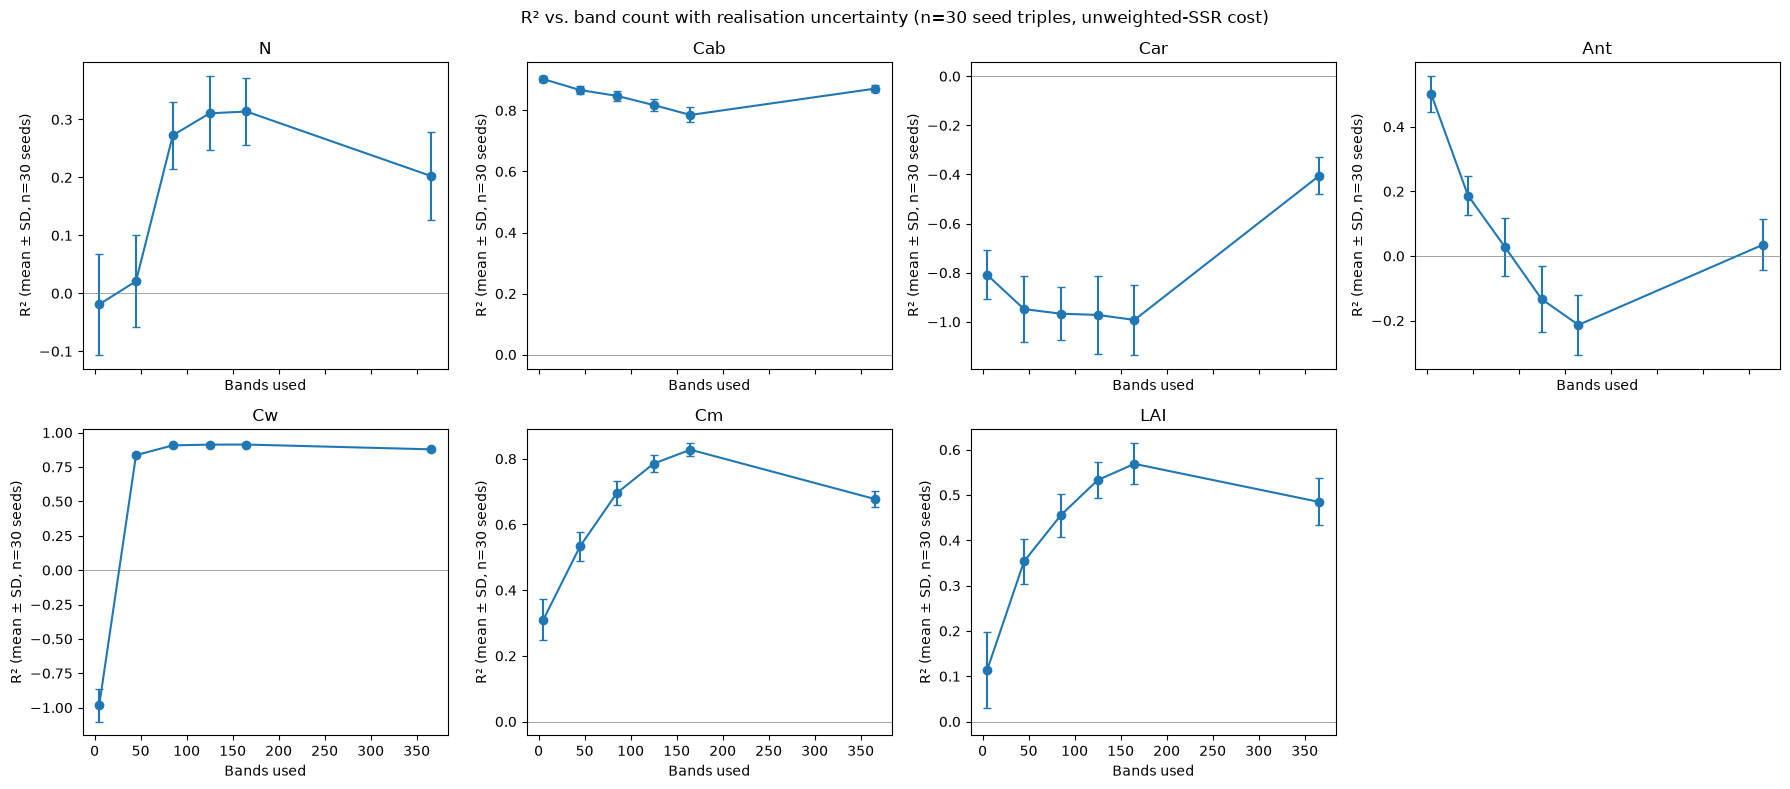

In [5]:
param_names = df["parameter"].unique()
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True)
for ax, param in zip(axes.flat, param_names):
    sub = sse_summary[sse_summary["parameter"] == param].set_index("subset").loc[subset_labels]
    ax.errorbar(sub["n_bands"], sub["r_squared_mean"], yerr=sub["r_squared_sd"], marker="o", capsize=3)
    ax.set_title(param)
    ax.set_xlabel("Bands used")
    ax.set_ylabel("R\u00b2 (mean \u00b1 SD, n=30 seeds)")
    ax.axhline(0, color="gray", lw=0.5)
axes.flat[-1].axis("off")
plt.suptitle(f"R\u00b2 vs. band count with realisation uncertainty (n={N_SEEDS} seed triples, unweighted-SSR cost)")
plt.tight_layout()
plt.savefig("../results/figures/06_multiseed_R2_vs_subset.png", dpi=150)
plt.show()

### Acceptance check: does the ±100 nm-vs-full Cw gap exceed ~1 SD?

In [6]:
r2_100 = cw_sse.loc["+ SWIR window \u00b1100 nm", "r_squared_mean"]
sd_100 = cw_sse.loc["+ SWIR window \u00b1100 nm", "r_squared_sd"]
r2_full = cw_sse.loc["Full hyperspectral (valid bands)", "r_squared_mean"]
sd_full = cw_sse.loc["Full hyperspectral (valid bands)", "r_squared_sd"]
gap = r2_100 - r2_full
pooled_sd = np.sqrt(sd_100**2 + sd_full**2)
print(f"Cw R\u00b2: \u00b1100nm = {r2_100:.3f} \u00b1 {sd_100:.3f}, full = {r2_full:.3f} \u00b1 {sd_full:.3f}")
print(f"Gap = {gap:.3f}, pooled SD = {pooled_sd:.3f}, gap/pooled_SD = {gap/pooled_sd:.2f}")

Cw R²: ±100nm = 0.907 ± 0.010, full = 0.878 ± 0.011
Gap = 0.029, pooled SD = 0.015, gap/pooled_SD = 1.99


## A2 result — cost-function ablation: does "targeted SWIR ≥ full hyperspectral" survive?

In [7]:
cost_ablation = summary[summary["parameter"].isin(["Cw", "Cm"])].copy()
cost_ablation.to_csv("../results/tables/07_cost_ablation.csv", index=False)

pivot = cost_ablation.pivot_table(index=["parameter", "subset"], columns="cost", values="r_squared_mean")
pivot = pivot.reindex(subset_labels, level="subset")
pivot

cost                                        noise_normalized       sam  \
parameter subset                                                         
Cm        5-band multispectral (no SWIR)            0.268314 -0.624169   
          + SWIR window ±50 nm                      0.458132 -0.140503   
          + SWIR window ±100 nm                     0.564963  0.275737   
          + SWIR window ±150 nm                     0.736451  0.564931   
          + SWIR window ±200 nm                     0.786539  0.673175   
          Full hyperspectral (valid bands)          0.660520  0.515934   
Cw        5-band multispectral (no SWIR)           -0.986446 -1.011744   
          + SWIR window ±50 nm                      0.804581  0.849306   
          + SWIR window ±100 nm                     0.864202  0.914541   
          + SWIR window ±150 nm                     0.905719  0.917254   
          + SWIR window ±200 nm                     0.906400  0.917319   
          Full hyperspectral (valid bands)          0.876222  0.889005   

cost                                             sse  
parameter subset                                      
Cm        5-band multispectral (no SWIR)    0.309412  
          + SWIR window ±50 nm              0.533362  
          + SWIR window ±100 nm             0.695687  
          + SWIR window ±150 nm             0.785308  
          + SWIR window ±200 nm             0.827672  
          Full hyperspectral (valid bands)  0.677129  
Cw        5-band multispectral (no SWIR)   -0.982775  
          + SWIR window ±50 nm              0.835990  
          + SWIR window ±100 nm             0.907053  
          + SWIR window ±150 nm             0.912500  
          + SWIR window ±200 nm             0.913076  
          Full hyperspectral (valid bands)  0.878135

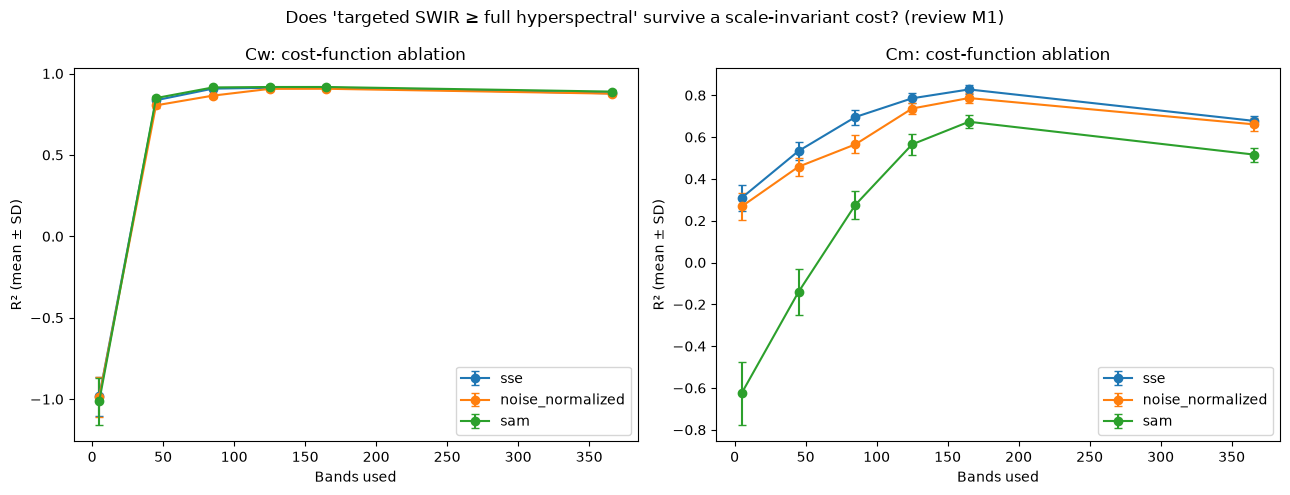

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, param in zip(axes, ["Cw", "Cm"]):
    for cost in ["sse", "noise_normalized", "sam"]:
        sub = summary[(summary["parameter"] == param) & (summary["cost"] == cost)].set_index("subset").loc[subset_labels]
        ax.errorbar(sub["n_bands"], sub["r_squared_mean"], yerr=sub["r_squared_sd"], marker="o", capsize=3, label=cost)
    ax.set_xlabel("Bands used")
    ax.set_ylabel("R\u00b2 (mean \u00b1 SD)")
    ax.set_title(f"{param}: cost-function ablation")
    ax.legend()
plt.suptitle("Does 'targeted SWIR \u2265 full hyperspectral' survive a scale-invariant cost? (review M1)")
plt.tight_layout()
plt.savefig("../results/figures/07_cost_ablation.png", dpi=150)
plt.show()

## Next steps

`07_k_best_cost_valley.ipynb` adds the k-best / cost-valley diagnostic (review M3) for the Car/Ant ill-posedness claim. Findings from both notebooks feed `RESPONSE_TO_REVIEW.md` and the manuscript revision (Task B).